## Thera Bank Personal Loan Campaign

### 1]  Import the datasets and libraries, check datatype, statistical summary,shape,null values or incorrect imputation. (5 marks)

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
## importing libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

In [3]:
# importing data

df = pd.read_csv("Bank_Personal_Loan_Modelling.csv")
df.head()      # used to see top 5 rows of the dataset

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [4]:
df.shape

(5000, 14)

In [5]:
df.dtypes        ## this would give datatype of each column

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

In [6]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [7]:
#There are negative numbmers in experience! maybe typing error. 
# Convert to non-negative using .abs function

df['Experience'] = df['Experience'].abs()

df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.134600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.415189,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,0.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [8]:
df.isnull().sum()  #check for null Values

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

## EDA

### 2]  EDA: Study the data distribution in each attribute and target variable, share your findings (20 marks)

Number of unique in each column?

Number of people with zero mortgage?

Number of people with zero credit card spending per month?

Value counts of all categorical columns.

Univariate and Bivariate

Get data model ready

In [9]:
# Column descriptions

## Data Description:

##	ID	Customer ID

##	Age	Customer's age in completed years

##	Experience	#years of professional experience

##	Income	Annual income of the customer ($000)

##	ZIPCode	Home Address ZIP code.

##	Family	Family size of the customer

##	CCAvg	Avg. spending on credit cards per month ($000)

##	Education	Education Level. 1: Undergrad; 2: Graduate; 3: Advanced/Professional

##	Mortgage	Value of house mortgage if any. ($000)

##	Personal Loan	Did this customer accept the personal loan offered in the last campaign? 0 - False and 1 - True

##	Securities Account	Does the customer have a securities account with the bank? 0 - False and 1 - True

##	CD Account	Does the customer have a certificate of deposit (CD) account with the bank? 0 - False and 1 - True

##	Online	Does the customer use internet banking facilities? 0 - False and 1 - True

##	CreditCard	Does the customer use a credit card issued by UniversalBank? 0 - False and 1 - True

In [10]:
df.nunique()
# gives number of unique values in each column

ID                    5000
Age                     45
Experience              44
Income                 162
ZIP Code               467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Personal Loan            2
Securities Account       2
CD Account               2
Online                   2
CreditCard               2
dtype: int64

In [11]:
df.drop(['ID','ZIP Code'],axis=1,inplace=True)

# dropping 'ID' column as it all the unique value and this column wont provide any insight to build a model
# Zip Code represents region and region wise distribution of customers is not helping here
# as alot region are there in just 5000 customers, therefore dropping 'ZIP Code'

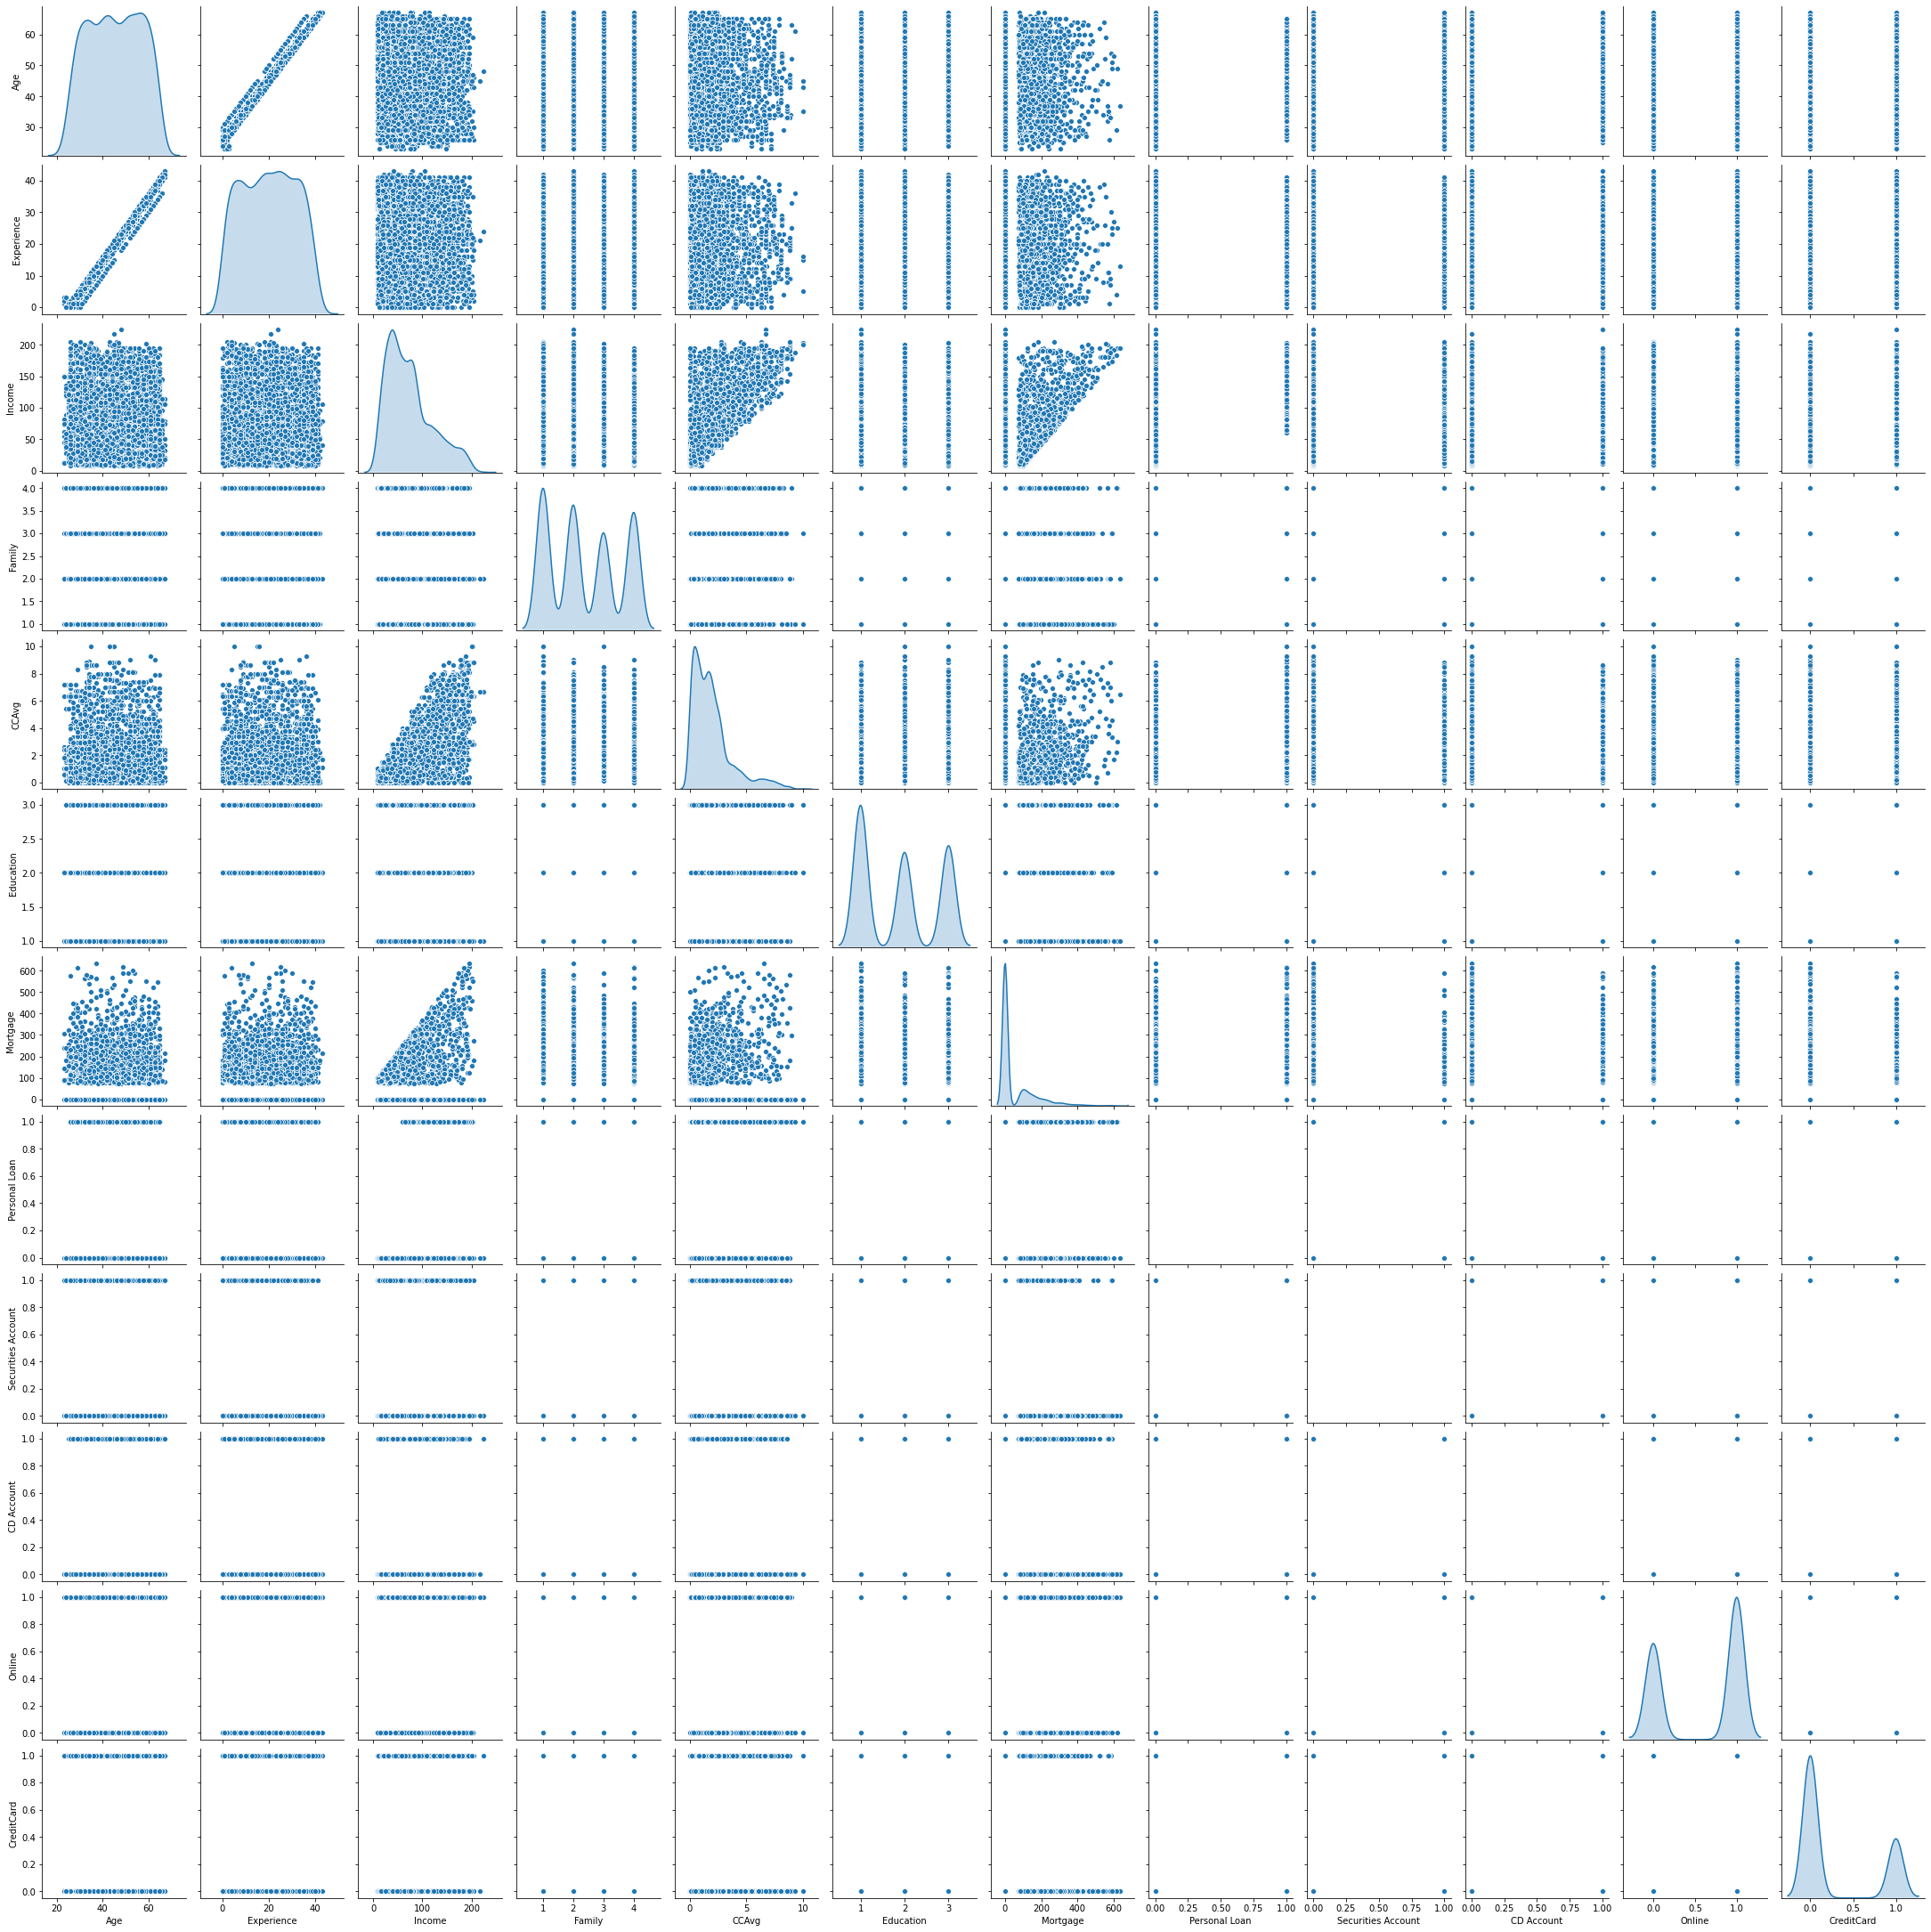

In [12]:
sns.pairplot(df, diag_kind='kde')
plt.show()

In [13]:
# Age and experience have strong positive relation
# Age and Experience have uniform distribution
# Income is positively skewed

### Target Variable is Personal Loan

In [14]:
vc = df[['Personal Loan', 'Securities Account', 'CD Account',
       'Online', 'CreditCard']].sum().reset_index().rename(columns={'index':'Col_Name',0:"Value_Count_1"})
vc['Value_Count_0'] = df.shape[0] - vc['Value_Count_1']
vc

# Value counts of all the category column with two unique values (0,1)

,Col_Name,Value_Count_1,Value_Count_0
0,Personal Loan,480,4520
1,Securities Account,522,4478
2,CD Account,302,4698
3,Online,2984,2016
4,CreditCard,1470,3530


0    90.4
1     9.6
Name: Personal Loan, dtype: float64



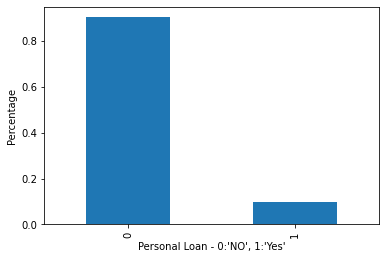

In [15]:
print(df['Personal Loan'].value_counts(normalize=True)*100)
print()
df['Personal Loan'].value_counts(normalize=True).plot(kind='bar')
plt.xlabel("Personal Loan - 0:'NO', 1:'Yes'")
plt.ylabel("Percentage")
plt.show()

In [16]:
df[df['Mortgage']==0].shape[0]

#count of people having home mortgage as zero, Most of the people donot have mortgage

3462

In [17]:
pd.crosstab(df['Personal Loan'], df['CreditCard'],normalize='all')

CreditCard,0,1
Personal Loan,,
0,0.6386,0.2654
1,0.0674,0.0286


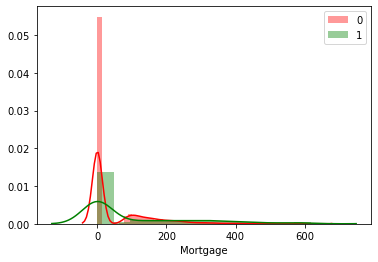

In [18]:
sns.distplot(df[df['Personal Loan']==0]['Mortgage'],color='r',label=0)
sns.distplot(df[df['Personal Loan']==1]['Mortgage'],color='g',label=1)
plt.legend()
plt.show()

# Most people with zero motgage are not taking personal loans

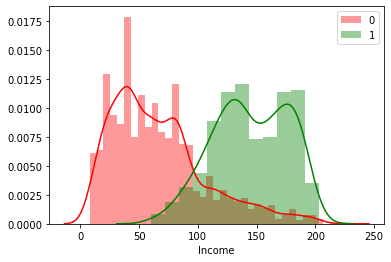

In [19]:
sns.distplot(df[df['Personal Loan']==0]['Income'],color='r',label=0)
sns.distplot(df[df['Personal Loan']==1]['Income'],color='g',label=1)
plt.legend()
plt.show()

# Number of People with high income taking personal loan are high as compared to low income

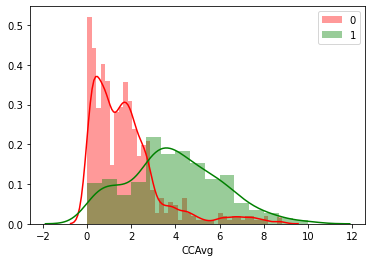

In [20]:
sns.distplot(df[df['Personal Loan']==0]['CCAvg'],color='r',label=0)
sns.distplot(df[df['Personal Loan']==1]['CCAvg'],color='g',label=1)
plt.legend()
plt.show()

# People with high avg credit card spending per month are taking personal loans

In [21]:
df[df['CCAvg']==0].shape[0]

#count of people having zero monthly spending on credit card

106

In [22]:
df['Family'] = df['Family'].astype('category')
df['Education'] = df['Education'].astype('category')

### 3]  	Split the data into training and test set in the ratio of 70:30 respectively (5 marks)

In [23]:
# Separate the independent attributes i.e. every column except personal loan
# Store the target column (Personal Loan) into Y array

x = df.loc[:, df.columns != 'Personal Loan']  # independent variables

y = df.loc[:, df.columns == 'Personal Loan']  # Target variable


In [24]:
x = pd.get_dummies(x,drop_first=True)

In [25]:
y.head()

,Personal Loan
0,0
1,0
2,0
3,0
4,0


In [26]:
x.head()

,Age,Experience,Income,CCAvg,Mortgage,Securities Account,CD Account,Online,CreditCard,Family_2,Family_3,Family_4,Education_2,Education_3
0,25,1,49,1.6,0,1,0,0,0,0,0,1,0,0
1,45,19,34,1.5,0,1,0,0,0,0,1,0,0,0
2,39,15,11,1.0,0,0,0,0,0,0,0,0,0,0
3,35,9,100,2.7,0,0,0,0,0,0,0,0,1,0
4,35,8,45,1.0,0,0,0,0,1,0,0,1,1,0


### 4]  Use Logistic Regression model to predict the likelihood of a customer buying personal loans. Print all the metrics related for evaluating the model performance (15 marks)

In [27]:
# Create the training and test data set in the ratio of 70:30 respectively. Can be of any ratio...

from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.3,random_state=7)

# Random state seeding for reapeatability of the code
# if random state is not mentioned it would generate different train test sample in every run
# test_size is to select the size of test data

# two variables taken for split therefore output will generate 4 variables: test train for x and test train for y

In [28]:
xtrain.head()

,Age,Experience,Income,CCAvg,Mortgage,Securities Account,CD Account,Online,CreditCard,Family_2,Family_3,Family_4,Education_2,Education_3
717,59,34,94,0.5,0,0,0,0,1,0,1,0,0,0
2496,63,37,32,0.7,141,0,0,0,0,0,1,0,1,0
2469,43,18,89,0.1,307,0,0,0,1,0,0,0,1,0
1375,50,26,179,2.9,0,0,0,0,1,0,0,0,0,1
2742,39,14,89,0.4,0,0,0,1,0,1,0,0,0,0


In [29]:
xtest.head()

,Age,Experience,Income,CCAvg,Mortgage,Securities Account,CD Account,Online,CreditCard,Family_2,Family_3,Family_4,Education_2,Education_3
3406,42,12,34,2.0,0,0,0,0,1,0,1,0,0,1
757,52,28,81,1.8,0,1,0,0,0,0,1,0,1,0
3624,58,28,70,1.4,0,0,0,0,0,0,0,0,0,1
4544,28,4,80,2.5,0,0,0,1,0,0,1,0,0,0
3235,60,35,39,1.6,0,0,0,1,0,1,0,0,0,1


#### Base Model

In [30]:
from sklearn.linear_model import LogisticRegression   # importing logistic regression from scikit learn

model = LogisticRegression(random_state=7)  #assigning a variable for the algorithm

model.fit(xtrain, ytrain) #training of model

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=7, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [31]:
y_predict = model.predict(xtest)     #model is predicting y values based on test dataset given to the model

print("Trainig accuracy",model.score(xtrain,ytrain))  # this will give training accuracy as training data has been used
print()
print("Testing accuracy",model.score(xtest, ytest))   # this will give testing accuracy as testing data has been used

Trainig accuracy 0.9568571428571429

Testing accuracy 0.9613333333333334


In [32]:
#### Here the model performs better in testing than training. Therefore, it is a good model

In [33]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score

## importing necessary metrics to evaluate model performance

In [34]:
## function to get confusion matrix in a proper format
def draw_cm( actual, predicted ):
    cm = confusion_matrix( actual, predicted)
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels = [0,1] , yticklabels = [0,1] )
    plt.ylabel('Observed')
    plt.xlabel('Predicted')
    plt.show()

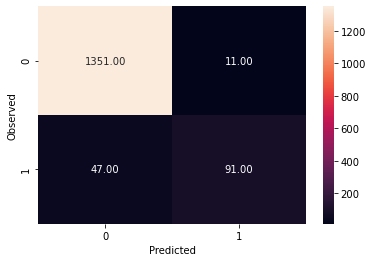

In [35]:
draw_cm(ytest,y_predict)

In [36]:
recall_score(ytest,y_predict)

0.6594202898550725

In [37]:
precision_score(ytest,y_predict)

0.8921568627450981

In [38]:
f1_score(ytest,y_predict)

0.7583333333333333

In [39]:
roc_auc_score(ytest,y_predict)

0.825671965779225

In [40]:
# !pip install yellowbrick

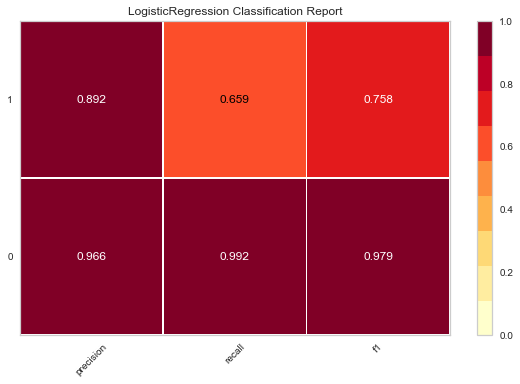

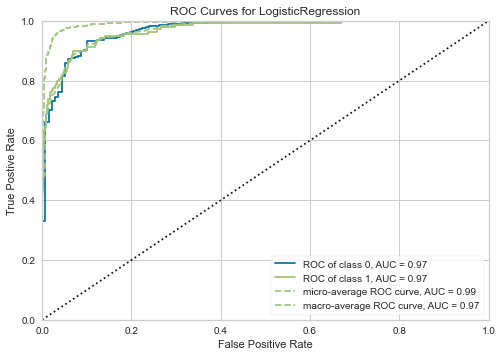

<AxesSubplot:title={'center':'ROC Curves for LogisticRegression'}, xlabel='False Positive Rate', ylabel='True Postive Rate'>

In [41]:
# Additional

from yellowbrick.classifier import ClassificationReport, ROCAUC
# Visualize model performance with yellowbrick library
viz = ClassificationReport(model)
viz.fit(xtrain, ytrain)
viz.score(xtest, ytest)
viz.show()

roc = ROCAUC(model)
roc.fit(xtrain, ytrain)
roc.score(xtest, ytest)
roc.show()

### 5]  Give your reasoning on how can the model perform better? (10 marks)

Hint: Check parameters

In [42]:
# Checking Parameters of logistic regression
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 7,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [43]:
#If we dont specify the parameters in the model it takes default value

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Please refer above link for the details of parameters

In [44]:
# Running a loop to check different values of 'solver'
# all solver can be used with l2, only 'liblinear' and 'saga' works with both 'l1' and 'l2'

train_score=[]
test_score=[]
solver = ['newton-cg','lbfgs','liblinear','sag','saga']
for i in solver:
    model = LogisticRegression(random_state=7,penalty='l2', solver=i)  # changing values of solver
    model.fit(xtrain, ytrain) 
    y_predict = model.predict(xtest)     
    train_score.append(round(model.score(xtrain,ytrain),3))
    test_score.append(round(model.score(xtest, ytest),3))
    
print(solver)
print()
print(train_score)
print()
print(test_score)

['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']

[0.958, 0.957, 0.958, 0.901, 0.903]

[0.964, 0.961, 0.965, 0.911, 0.913]


In [45]:
train_score=[]
test_score=[]
solver = ['liblinear','saga']  # changing values of solver which works with 'l1'
for i in solver:
    model = LogisticRegression(random_state=7,penalty='l1', solver=i)  # changed value of penaly to 'l1'
    model.fit(xtrain, ytrain) 
    y_predict = model.predict(xtest)     
    train_score.append(round(model.score(xtrain,ytrain),3))
    test_score.append(round(model.score(xtest, ytest),3))
    
print(solver)
print()
print(train_score)
print()
print(test_score)

['liblinear', 'saga']

[0.959, 0.903]

[0.965, 0.913]


In [46]:
## Highest accuracy is same 'l1' with 'liblinear' and 'l2' with 'lbfgs'
# choose any one

In [47]:
model = LogisticRegression(random_state=7,penalty='l1',solver='liblinear',class_weight='balanced') # changing class weight to balanced

model.fit(xtrain, ytrain) 

y_predict = model.predict(xtest)     

print("Trainig accuracy",model.score(xtrain,ytrain))  
print()
print("Testing accuracy",model.score(xtest, ytest))   

Trainig accuracy 0.8997142857142857

Testing accuracy 0.9073333333333333


In [48]:
## Accuracy decreased so removing class weight from the model

In [49]:
# Running a loop to check different values of 'C'

train_score=[]                                 
test_score=[]
C = [0.01,0.1,0.25,0.5,0.75,1]
for i in C:
    model = LogisticRegression(random_state=7,penalty='l1',solver='liblinear', C=i)  # changing values of C
    model.fit(xtrain, ytrain) 
    y_predict = model.predict(xtest)     
    train_score.append(round(model.score(xtrain,ytrain),3)) # appending training accuracy in a blank list for every run of the loop
    test_score.append(round(model.score(xtest, ytest),3))   # appending testing accuracy in a blank list for every run of the loop
    
print(C)
print()
print(train_score)
print()
print(test_score)

[0.01, 0.1, 0.25, 0.5, 0.75, 1]

[0.902, 0.952, 0.958, 0.958, 0.959, 0.959]

[0.913, 0.955, 0.96, 0.963, 0.965, 0.965]


In [50]:
## Best testing accuracy is obtained for C=1, which is default

Trainig accuracy 0.9591428571428572

Testing accuracy 0.9646666666666667

Confusion Matrix


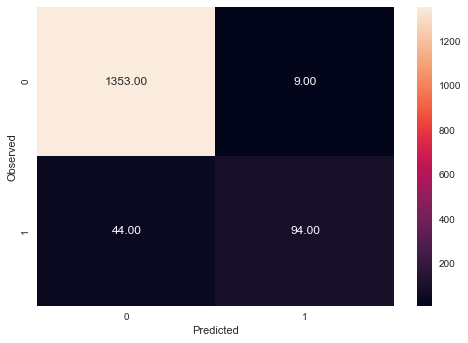

None

Recall: 0.6811594202898551

Precision: 0.912621359223301

F1 Score: 0.7800829875518673

Roc Auc Score: 0.8372757453872183


In [51]:
#Therefore final model is
model = LogisticRegression(random_state=7,penalty='l1',solver='liblinear') 
model.fit(xtrain, ytrain)
y_predict = model.predict(xtest)
print("Trainig accuracy",model.score(xtrain,ytrain))  
print()
print("Testing accuracy",model.score(xtest, ytest))
print()
print('Confusion Matrix')
print(draw_cm(ytest,y_predict))
print()
print("Recall:",recall_score(ytest,y_predict))
print()
print("Precision:",precision_score(ytest,y_predict))
print()
print("F1 Score:",f1_score(ytest,y_predict))
print()
print("Roc Auc Score:",roc_auc_score(ytest,y_predict))

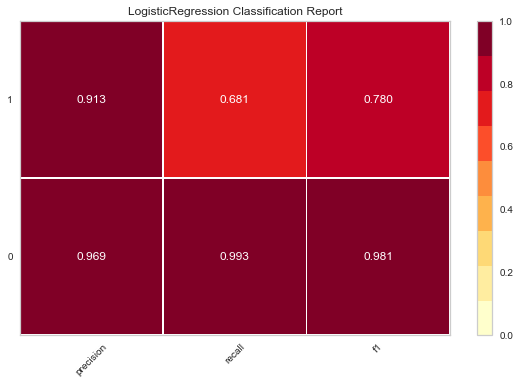

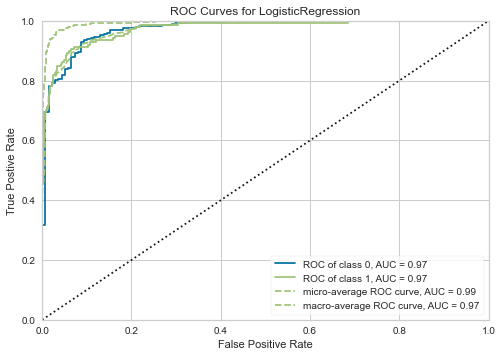

<AxesSubplot:title={'center':'ROC Curves for LogisticRegression'}, xlabel='False Positive Rate', ylabel='True Postive Rate'>

In [52]:
# Additional

from yellowbrick.classifier import ClassificationReport, ROCAUC
# Visualize model performance with yellowbrick library
viz = ClassificationReport(model)
viz.fit(xtrain, ytrain)
viz.score(xtest, ytest)
viz.show()

roc = ROCAUC(model)
roc.fit(xtrain, ytrain)
roc.score(xtest, ytest)
roc.show()

### 6] Give Business understanding of your model? (5 marks)

**Confusion matrix means**

*True Positive (observed=1,predicted=1):*

Predicted Personal loan will be taken and the customer took it

*False Positive (observed=0,predicted=1):*

Predicted Personal loan will be taken and the customer did not take it

*True Negative (observed=0,predicted=0):*

Predicted Personal loan will not be taken and the customer did not take it

*False Negative (observed=1,predicted=0):*

Predicted Personal loan will not be taken and the customer took it

Here more focus towards should be towards recall because our target variable is 'Personal Loan' , i.e whether the customer is accepting the personal loan or not. And the bank wants more people to accept personal loan i.e. less number of False Negative, so that bank doesn't lose real customers who want to take loan. Hence the focus should be on increasing Recall.

After achieving the desired accuracy we can deploy the model for practical use. As in the bank now can predict who will say yes for the personnel loan. They can use the model for upcoming customers.